In [1]:
using CMPSExcitations

In [2]:
Hsingle(c, μ) = ∫(2 * ∂ψ̂' * ∂ψ̂ - 2 * μ * ψ̂' * ψ̂ + 4 * c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));
Hcoupled(c, μ) = ∫(
    (∂ψ̂₁' * ∂ψ̂₁ - μ * ψ̂₁' * ψ̂₁ + c * (ψ̂₁')^2 * ψ̂₁^2 +
     ∂ψ̂₂' * ∂ψ̂₂ - μ * ψ̂₂' * ψ̂₂ + c * (ψ̂₂')^2 * ψ̂₂^2 +
     2 * c * (ψ̂₁') * (ψ̂₂') * ψ̂₂ * ψ̂₁), (-Inf, +Inf));

In [25]:
c, μ = 10., 5.
tol = 1e-10
HLL = Hsingle(c, μ)

Ds = [2]
stateLL = find_groundstate(Ds, HLL, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
D = maximum(Ds)
println("Energy density: ", expval(HLL.h, stateLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateLL)[], "\n Order parameter: ", expval(ψ̂, stateLL)[])

Optimizing D=2
D = 2 | YangGaudinCMPS{Constant{Matrix{Float64}}, 1}
  0.003786 seconds (34.17 k allocations: 1.265 MiB)
---------------
Energy density: -2.555100535380943
 Particle density: 0.40598711566372797
 Order parameter: -0.5119596774277507


┌ Info: YangGaudinCMPS ground state: initialization with e = 594.827651512075
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:106
┌ Info: LBFGS: converged after 25 iterations: f = -2.555100535381, ‖∇f‖ = 3.1699e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138
┌ Info: YangGaudinCMPS ground state: converged after 26 iterations: e = -2.555100535381, ‖∇e‖ = 3.1699e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:118


In [26]:
stateCLL = InfiniteCMPS(stateLL.Q, (stateLL.Rs[1], stateLL.Rs[1]));
HCLL = Hcoupled(c, μ)
println("Energy density: ", expval(HCLL.h, stateCLL)[], "\nParticle density: ", expval(ψ̂₁' * ψ̂₁ + ψ̂₂' * ψ̂₂, stateCLL)[], "\nDensity imbalance: ", expval(ψ̂₁' * ψ̂₁ - ψ̂₂' * ψ̂₂, stateCLL)[])
leftgauge!(stateCLL)

Energy density: -2.5551005353809435
Particle density: 0.8119742313274557
Density imbalance: 0.0


(InfiniteCMPS{Constant{Matrix{Float64}}, 2}(Constant{Matrix{Float64}}(Base.RefValue{Matrix{Float64}}([-0.026732579925279554 0.8433600747757819; -1.2224594247791698 -1.47844845229335])), (Constant{Matrix{Float64}}(Base.RefValue{Matrix{Float64}}([0.13374209054185315 1.159217475030404; -0.09405122616306662 -0.3669649818136369])), Constant{Matrix{Float64}}(Base.RefValue{Matrix{Float64}}([0.13374209054185315 1.159217475030404; -0.09405122616306662 -0.3669649818136369]))), :l), -4.218847493575595e-15, Constant{Matrix{Float64}}(Base.RefValue{Matrix{Float64}}([-0.7071067811865475 -0.0; 0.0 0.7071067811865475])), ConvergenceInfo: one converged value after 1 iterations and 1 applications of the linear map;
norms of residuals are given by 5.72e-15.)

In [27]:
# canonical basis
function projection_matrix(D, M)
    dim_in = D^2 + D      # input: E (DxD) + F (D)
    dim_out = 2 * D^2     # output: W1, W2 (both DxD)
    P = zeros(ComplexF64, dim_out, dim_in)

    for j in 1:dim_in
        e = zeros(Float64, dim_in)
        e[j] = 1.0

        E = reshape(view(e, 1:D^2), D, D)
        F = view(e, D^2+1:dim_in)

        W1 = E / sqrt(2) - M * Diagonal(F) / M
        W2 = E / sqrt(2) + M * Diagonal(F) / M

        P[:, j] = vcat(vec(W1), vec(W2))
    end

    return P
end

# canonical basis
function excitation_matrix(Heff, D)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        W1p, W2p = Heff((Constant(W1), Constant(W2)))
        M[:, j] = vcat(vec(W1p[]), vec(W2p[]))
    end

    return M
end

function excitation_matrix_constrained(Heff, M)
    D = size(M, 1) # R = MDᵣ/M
    H = excitation_matrix(Heff, D)
    P = projection_matrix(D, M)

    P' * H * P, P
end

excitation_matrix_constrained (generic function with 1 method)

In [34]:
_, M = eigen(stateLL.Rs[1][]);
P = projection_matrix(D, M)

Q = P[1:D^2, D^2+1:end]
Qn = Matrix(qr(Q).Q)
Pn = copy(P)
Pn[1:D^2, D^2+1:end] .= Qn / sqrt(2)
Pn[D^2+1:end, D^2+1:end] .= -Qn / sqrt(2);
Pn = Matrix(qr(P).Q);

In [35]:
space = InfiniteCMPSExcitationSpace(0, stateCLL, stateCLL)
Heff = excitation_matrix(excitation_operator(HCLL, space), D);

In [37]:
round.(Pn' * Heff * Pn, digits=2) |> display

6×6 Matrix{ComplexF64}:
 11.61+0.0im    -6.68+0.0im    16.79+0.0im   …   -0.0-1.1im     -0.0-0.28im
 -6.68+0.0im    48.77+0.0im   -24.34+0.0im       -0.0+4.18im     0.0+1.05im
 16.79+0.0im   -24.34+0.0im    52.46+0.0im        0.0-3.94im    -0.0-0.99im
 13.44+0.0im    17.55+0.0im    20.22+0.0im        0.0-1.8im     -0.0-0.45im
   0.0+1.1im     -0.0-4.18im     0.0+3.94im     24.29-0.0im    -1.45-20.45im
  -0.0+0.28im     0.0-1.05im    -0.0+0.99im  …  -1.45+20.45im  29.73+0.0im

### Explicitly constructing goldstone modes

In [20]:
# canonical basis
function projection_matrix(D, M)
    dim_in = D^2 + D      # input: E (DxD) + F (D)
    dim_out = 2 * D^2     # output: W1, W2 (both DxD)
    P = zeros(ComplexF64, dim_out, dim_in)

    for j in 1:dim_in
        e = zeros(Float64, dim_in)
        e[j] = 1.0

        E = reshape(view(e, 1:D^2), D, D)
        F = view(e, D^2+1:dim_in)

        W1 = E
        W2 = E + M * Diagonal(F) / M

        P[:, j] = vcat(vec(W1), vec(W2))
    end

    return Matrix(qr(P).Q) # moves to an orthogonal projection
end

# canonical basis
function excitation_matrix(Heff, D)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        W1p, W2p = Heff((Constant(W1), Constant(W2)))
        M[:, j] = vcat(vec(W1p[]), vec(W2p[]))
    end

    return M
end

function excitation_matrix_constrained(Heff, M)
    D = size(M, 1) # R = MDᵣ/M
    H = excitation_matrix(Heff, D)
    P = projection_matrix(D, M)

    P' * H * P, P
end

excitation_matrix_constrained (generic function with 1 method)

In [19]:
Hsingle_ll(c, μ) = ∫(∂ψ̂' * ∂ψ̂ - μ * ψ̂' * ψ̂ + c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));
c, μ = 10., 5.
tol = 1e-10
Ds = [4, 8]
D = maximum(Ds)

HLL = Hsingle(c, μ)
stateLL = find_groundstate(Ds, HLL, InfiniteCMPS, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
println("Energy density: ", expval(HLL.h, stateLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateLL)[], "\n Order parameter: ", expval(ψ̂, stateLL)[])

HCLL = Hcoupled(c, μ)
stateCLL = InfiniteCMPS(stateLL.Q, (stateLL.Rs[1], stateLL.Rs[1]));
println("Energy density: ", expval(HCLL.h, stateCLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateCLL)[], "\n Order parameter: ", expval(ψ̂, stateCLL)[])

Optimizing D=4


┌ Info: UniformCMPS ground state: initialization with e = 1176.846401464818
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:115
┌ Info: LBFGS: converged after 168 iterations: f = -5.050019379406, ‖∇f‖ = 1.5738e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138


D = 4 | InfiniteCMPS{Constant{Matrix{Float64}}, 1}
  2.951878 seconds (11.64 M allocations: 588.709 MiB, 2.02% gc time, 96.06% compilation time)
---------------
Optimizing D=8


┌ Info: UniformCMPS ground state: converged after 169 iterations: e = -5.050019379406, ‖∇e‖ = 1.5738e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:127
┌ Info: UniformCMPS ground state: initialization with e = -5.050019379113
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:115
┌ Info: LBFGS: converged after 409 iterations: f = -5.101997460806, ‖∇f‖ = 7.5490e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138


D = 8 | InfiniteCMPS{Constant{Matrix{Float64}}, 1}
  3.594049 seconds (5.54 M allocations: 446.821 MiB, 1.50% gc time, 6.85% compilation time)
---------------
Energy density: -5.101997460806064
 Particle density: 0.7850064187771219
 Order parameter: -0.43098279532537453
Energy density: -2.655241675469504

┌ Info: UniformCMPS ground state: converged after 410 iterations: e = -5.101997460806, ‖∇e‖ = 7.5490e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:127



 Particle density: 0.40133751372596543
 Order parameter: -0.3092564728805468


In [14]:
leftgauge!(stateCLL)
Q, R = stateCLL.Q[], stateCLL.Rs[1][];
W1, W2 = R, -R;

function leftgaugetv(Q, R, V, W1, W2, p)
    # assuming Q, R are in cMPS left gauge
    X, _ = linsolve(-R' * (W1 + W2) - V) do X
        (Q * X - X * Q) + 1im * p * X + 2 * R' * (R * X - X * R)
    end

    return V + (Q * X - X * Q) + 1im * p * X, W1 + (R * X - X * R), W2 + (R * X - X * R)
end

ps = range(0, 5., 20)
energies = zeros(ComplexF64, length(ps))
ρr = rightenv(stateCLL)[1][]

Threads.@threads for idx in eachindex(ps)
    V, W1, W2 = leftgaugetv(Q, R, zero(Q), R, -R, ps[idx])
    # ∫⟨H⟩ - ⟨H₀⟩ = E -> intensive contribution to energy on top of extensive ground state energy
    space = InfiniteCMPSExcitationSpace(ps[idx], stateCLL, stateCLL)
    Heff, P = excitation_matrix_constrained(excitation_operator(HCLL, space), eigen(R).vectors)

    # Heff maps between D^2 + D subspace; so P * Heff * P' maps between 2D^2 space while keeping the multispecies constraint satisfied
    Ws = P * Heff * P' * vcat(vec(W1), vec(W2))

    HW1 = reshape(view(Ws, 1:D^2), D, D)
    HW2 = reshape(view(Ws, (D^2+1):2*D^2), D, D)

    energies[idx] = tr(HW1 * ρr * W1' + HW2 * ρr * W2')
end

energies

20-element Vector{ComplexF64}:
 2.0971674974785153e7 - 3.157460103000074e-8im
 2.1009778802388757e7 + 53424.76224753489im
 2.1124090285199527e7 + 106849.52449510121im
 2.1314609423217446e7 + 160274.28674266586im
 2.1581336216442622e7 + 213699.04899024364im
 2.1924270664874844e7 + 267123.8112378011im
 2.2343412768514317e7 + 320548.57348537655im
 2.2838762527361017e7 + 373973.33573293866im
  2.341031994141482e7 + 427398.0979805098im
 2.4058085010675818e7 + 480822.86022807256im
  2.478205773514399e7 + 534247.6224756392im
 2.5582238114819378e7 + 587672.3847232042im
 2.6458626149701893e7 + 641097.1469707731im
  2.741122183979161e7 + 694521.9092183409im
 2.8440025185088478e7 + 747946.6714659052im
  2.954503618559255e7 + 801371.4337134665im
 3.0726254841303807e7 + 854796.1959610386im
  3.198368115222221e7 + 908220.9582085996im
 3.3317315118347794e7 + 961645.7204561792im
  3.472715673968058e7 + 1.0150704827037328e6im

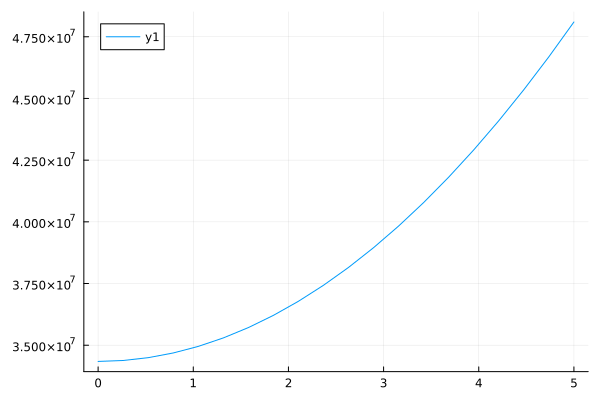

In [13]:
plot(ps, real.(energies))